1      2.564198
6      2.974710
2      3.164979
5      8.323240
0     12.144445
4     54.646143
3    109.987512
Name: FastKAN - self_cuda_time_total (ms), dtype: float64


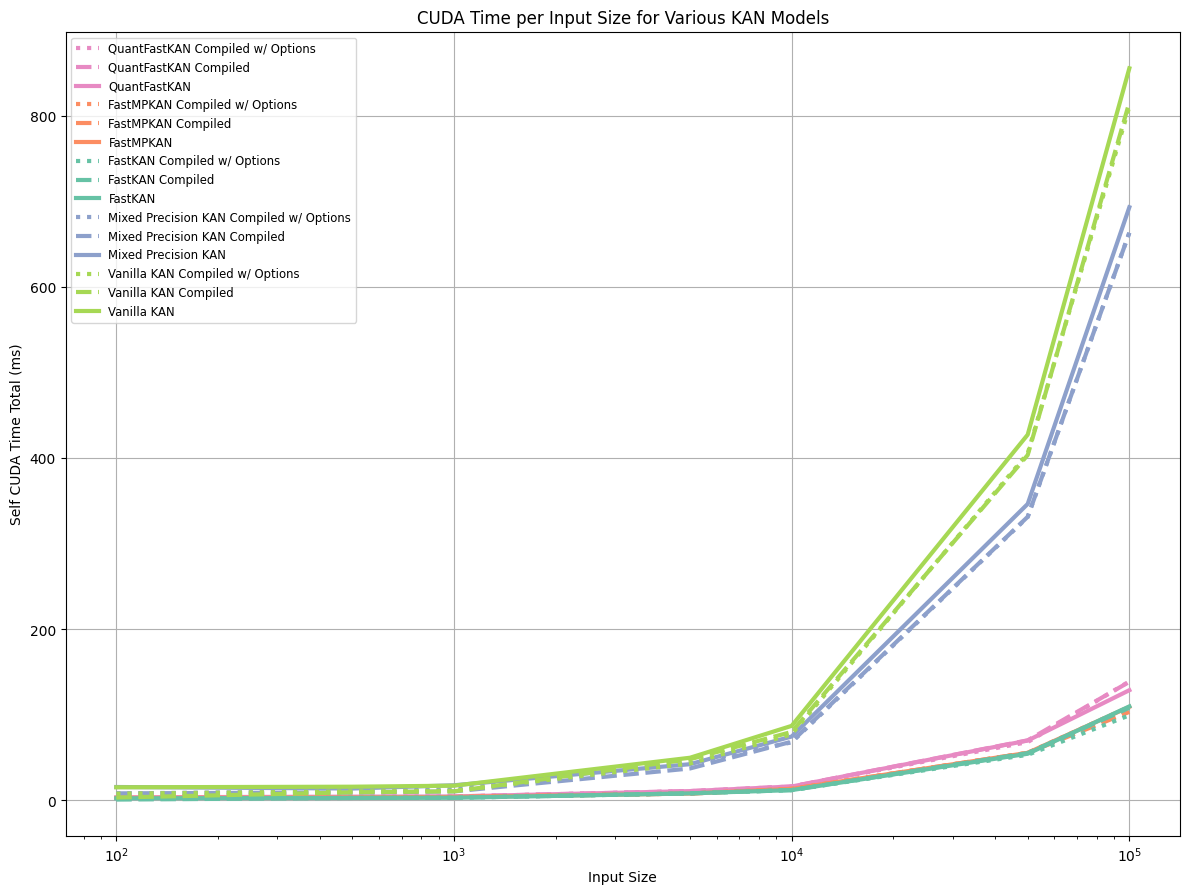

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

csv_data = './data/input_size__cuda_speedup.csv'

# Load the CSV content
df = pd.read_csv(csv_data)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(by='Input Size')
print(df['FastKAN - self_cuda_time_total (ms)'])

df.rename(columns=lambda x: x.replace(" - self_cuda_time_total (ms)", "") if " - self_cuda_time_total (ms)" in x else x, inplace=True)
# Filter columns that are not MIN or MAX
main_cols = [col for col in df.columns if '__MIN' not in col and '__MAX' not in col and col != 'Input Size']

# Extract first word of each column for color grouping
prefixes = [col.split()[0] for col in main_cols]
unique_prefixes = sorted(set(prefixes))

# Create a color map based on prefixes
set3 = plt.get_cmap('Set2')
prefix_color_map = {prefix: set3(i % set3.N) for i, prefix in enumerate(unique_prefixes)}

def get_line_style(name):
    if 'Compiled w/ Options' in name:
        return 'dotted'
    elif 'Compiled' in name:
        return 'dashed'
    else:
        return 'solid'

# Plot
plt.figure(figsize=(12, 9))
for col in main_cols:
    prefix = col.split()[0]
    linestyle = get_line_style(col)
    plt.plot(df['Input Size'], df[col], label=col, color=prefix_color_map[prefix], linestyle=linestyle, linewidth=3)

plt.xlabel('Input Size')
plt.ylabel('Self CUDA Time Total (ms)')
plt.title('CUDA Time per Input Size for Various KAN Models')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.show()


['Vanilla KAN Compiled w/ Options - self_cuda_time_total (ms)', 'Vanilla KAN Compiled - self_cuda_time_total (ms)', 'Vanilla KAN - self_cuda_time_total (ms)']


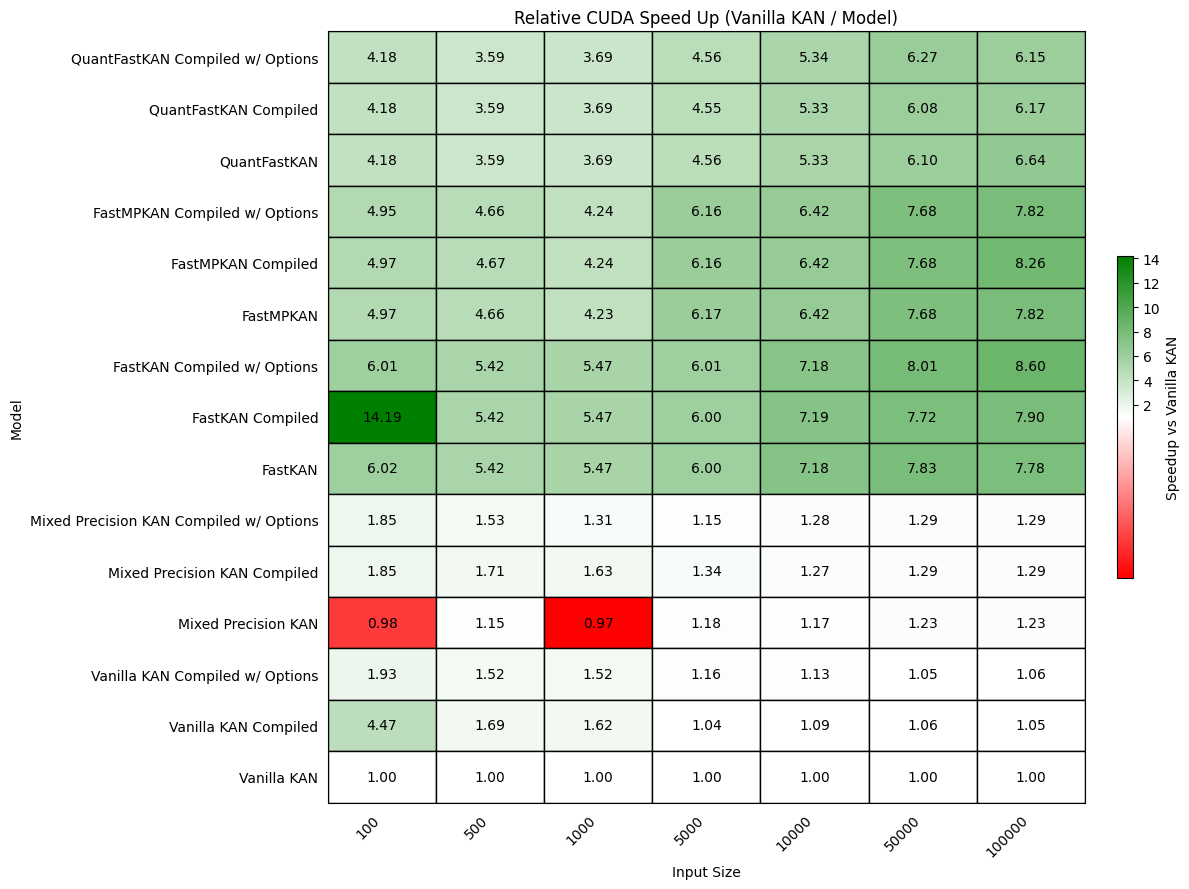

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

csv_data = './data/input_size__cuda_speedup.csv'

# Load the CSV content
df = pd.read_csv(csv_data)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# Find the main Vanilla KAN column
vanilla_kan_col = [col for col in df.columns if col.startswith("Vanilla KAN") and '__' not in col]
print(vanilla_kan_col)
vanilla_vals = df['Vanilla KAN - self_cuda_time_total (ms)']

# Compute ratios
heatmap_data = pd.DataFrame(index=[], columns=[])
input_sizes = df['Input Size']

for col in df.columns:
    if col == 'Input Size' or col == vanilla_kan_col or '__' in col:
        continue
    model_name = col.replace(" - self_cuda_time_total (ms)", "")
    ratios = (vanilla_vals.values / df[col].values)
    heatmap_data.loc[model_name, input_sizes] = ratios

# Ensure proper ordering
heatmap_data.columns = heatmap_data.columns.astype(int)
heatmap_data = heatmap_data.sort_index(axis=1)
data = heatmap_data.values.astype(float)
n_rows, n_cols = data.shape

# Create diverging colormap: green (fast), white (equal), red (slow)
cmap = mcolors.LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"])
norm = mcolors.TwoSlopeNorm(vmin=np.min(data), vcenter=1.0, vmax=np.max(data))

# Plot
fig, ax = plt.subplots(figsize=(12, max(2, len(heatmap_data)*0.6)))
for i in range(n_rows):
    for j in range(n_cols):
        value = data[i, j]
        color = cmap(norm(value))
        rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha="center", va="center", color="black")

# Axis setup
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)
ax.invert_yaxis()
ax.set_title('Relative CUDA Speed Up (Vanilla KAN / Model)')
ax.set_xlabel('Input Size')
ax.set_ylabel('Model')
ax.tick_params(top=False, bottom=False, left=False, right=False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label('Speedup vs Vanilla KAN')

plt.tight_layout()
plt.show()

['Vanilla KAN Compiled w/ Options - inference_time', 'Vanilla KAN Compiled - inference_time', 'Vanilla KAN - inference_time']
1.0 1 49.93245704400752


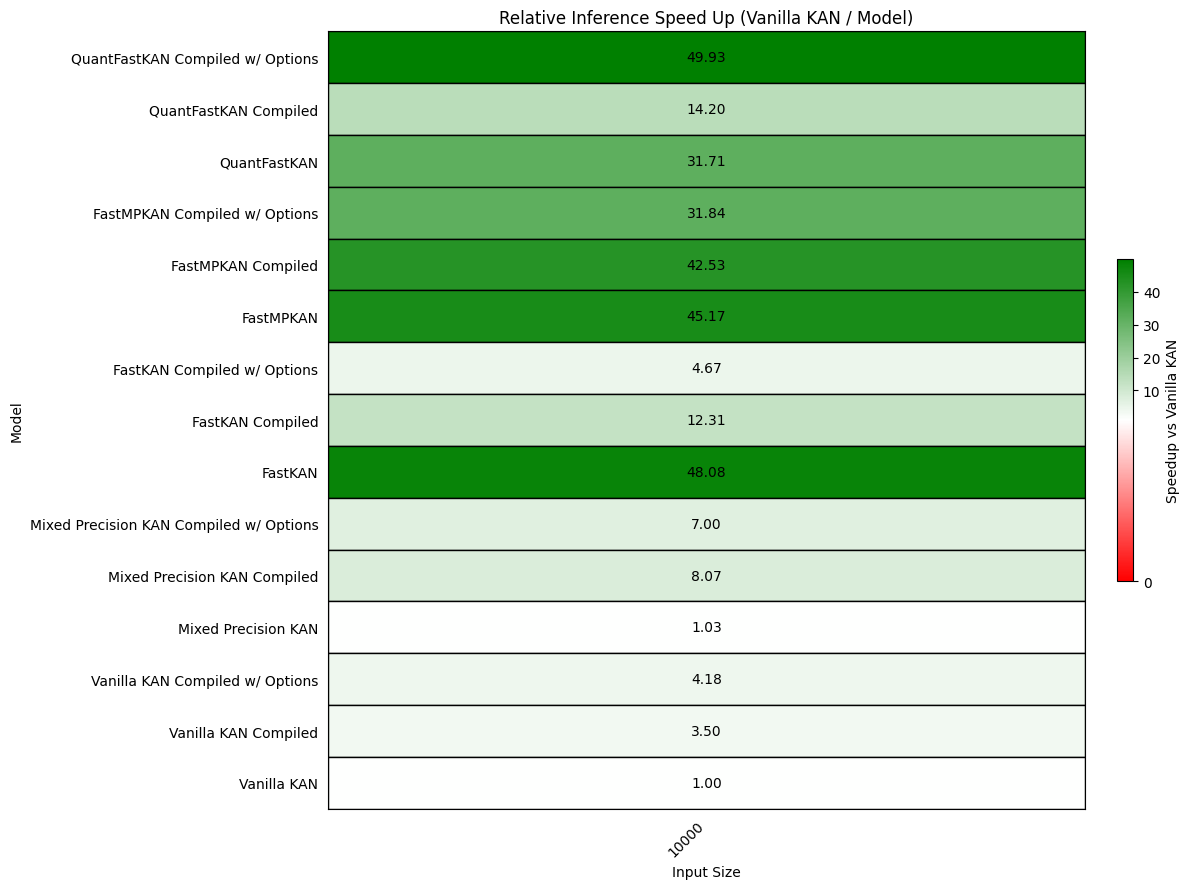

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

csv_data = './data/inference_times_speedup.csv'

# Load the CSV content
df = pd.read_csv(csv_data)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# Find the main Vanilla KAN column
vanilla_kan_col = [col for col in df.columns if col.startswith("Vanilla KAN") and '__' not in col]
print(vanilla_kan_col)
vanilla_vals = df['Vanilla KAN - inference_time']

# Compute ratios
heatmap_data = pd.DataFrame(index=[], columns=[])
input_sizes = df['Input Size']

for col in df.columns:
    if col == 'Input Size' or col == vanilla_kan_col or '__' in col:
        continue
    model_name = col.replace(" - inference_time", "")
    ratios = (vanilla_vals.values / df[col].values)
    heatmap_data.loc[model_name, input_sizes] = ratios

# Ensure proper ordering
heatmap_data.columns = heatmap_data.columns.astype(int)
heatmap_data = heatmap_data.sort_index(axis=1)
data = heatmap_data.values.astype(float)
n_rows, n_cols = data.shape

# Create diverging colormap: green (fast), white (equal), red (slow)
cmap = mcolors.LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"])
print(np.min(data), 1, np.max(data))
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=np.max(data))

# Plot
fig, ax = plt.subplots(figsize=(12, max(2, len(heatmap_data)*0.6)))
for i in range(n_rows):
    for j in range(n_cols):
        value = data[i, j]
        color = cmap(norm(value))
        rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha="center", va="center", color="black")

# Axis setup
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)
ax.invert_yaxis()
ax.set_title('Relative Inference Speed Up (Vanilla KAN / Model)')
ax.set_xlabel('Input Size')
ax.set_ylabel('Model')
ax.tick_params(top=False, bottom=False, left=False, right=False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label('Speedup vs Vanilla KAN')

plt.tight_layout()
plt.show()

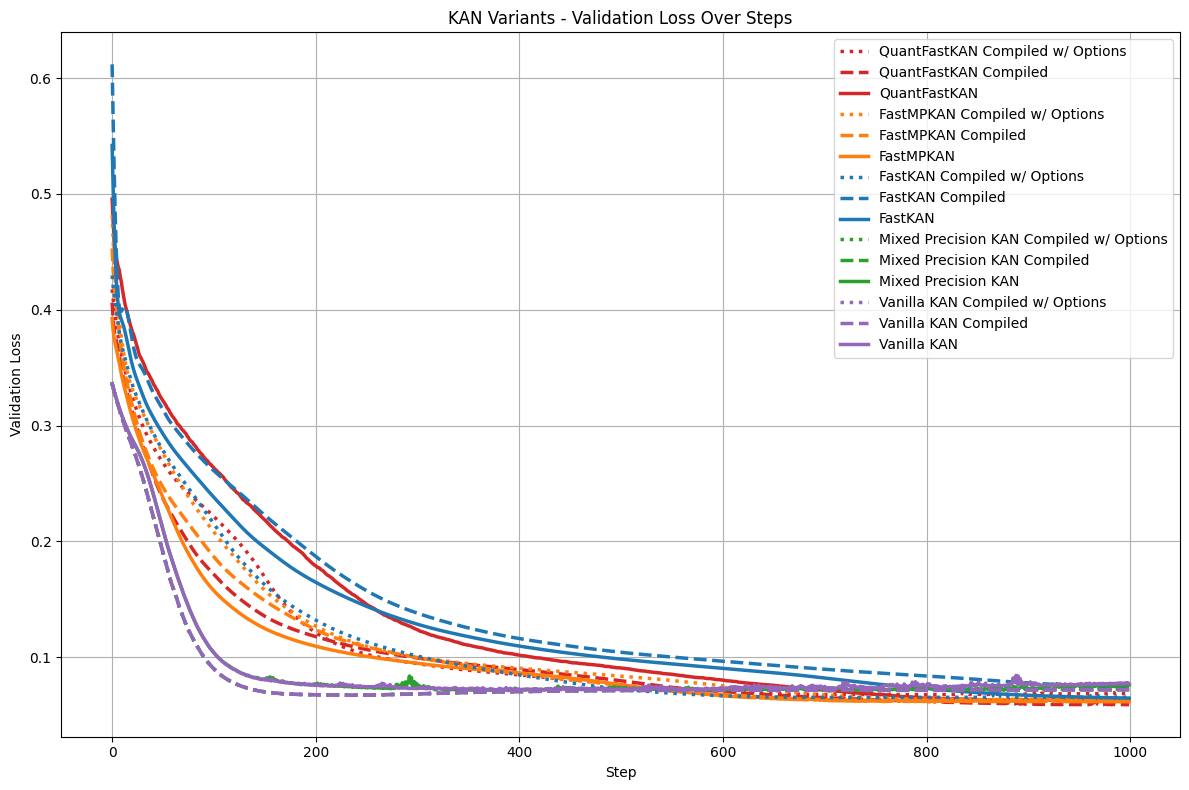

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("./data/kan_variations_val_loss.csv")

# Extract steps
steps = df["Step"]

# Filter relevant columns (exclude __MIN and __MAX)
val_loss_cols = [col for col in df.columns if "val_loss" in col and "__" not in col]

# Determine color groupings based on first word
prefixes = [col.split()[0] for col in val_loss_cols]
unique_prefixes = sorted(set(prefixes))

# Create color map
color_map = plt.get_cmap("tab10")
prefix_color_map = {prefix: color_map(i % 10) for i, prefix in enumerate(unique_prefixes)}

# Line style based on compile options
def get_line_style(name):
    if "Compiled w/ Options" in name:
        return 'dotted'
    elif "Compiled" in name:
        return 'dashed'
    else:
        return 'solid'

# Plot
plt.figure(figsize=(12, 8))
for col in val_loss_cols:
    prefix = col.split()[0]
    linestyle = get_line_style(col)
    label = col.replace(" - val_loss", "")
    plt.plot(steps, df[col], label=label, color=prefix_color_map[prefix], linestyle=linestyle, linewidth=2.5)

plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("KAN Variants - Validation Loss Over Steps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


['Vanilla KAN Compiled w/ Options - val_loss', 'Vanilla KAN Compiled - val_loss', 'Vanilla KAN - val_loss']


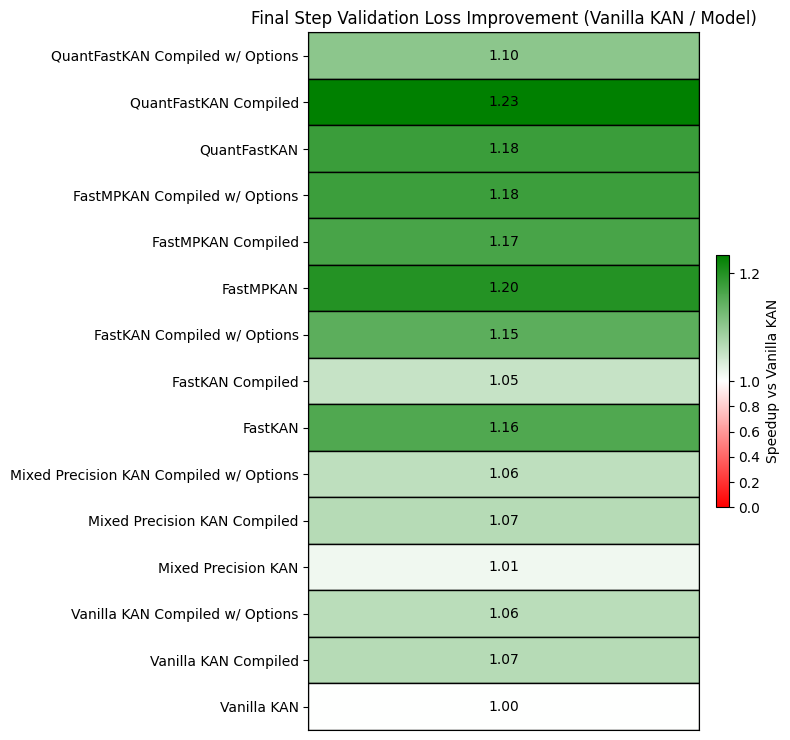

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Load CSV
df = pd.read_csv("./data/kan_variations_val_loss.csv")

# Filter relevant columns (exclude __MIN and __MAX)
val_loss_cols = [col for col in df.columns if "val_loss" in col and "__" not in col]

# Extract the final step (last row)
final_step = df.iloc[-1]

# Identify the Vanilla KAN column
vanilla_col = [col for col in val_loss_cols if col.startswith("Vanilla KAN")]
print(vanilla_col)

vanilla_val = final_step['Vanilla KAN - val_loss']

# Compute ratios (Vanilla KAN / Model)
ratios = {}
for col in val_loss_cols:
    model_name = col.replace(" - val_loss", "")
    model_val = final_step[col]
    # ratio = vanilla_val / model_val if model_val != 0 else np.nan
    ratio = (vanilla_val - model_val) / vanilla_val  + 1 if vanilla_val != 0 else np.nan
    ratios[model_name] = ratio

# Create DataFrame
heatmap_df = pd.DataFrame.from_dict(ratios, orient='index', columns=["Speedup"])
# heatmap_df = heatmap_df.sort_values(by="Speedup", ascending=False)

# Prepare for plotting
data = heatmap_df["Speedup"].values
model_names = heatmap_df.index.tolist()
n_models = len(data)

# Define colormap: red (<1), white (=1), green (>1)
cmap = mcolors.LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"])
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=np.max(data))

# Plot
fig, ax = plt.subplots(figsize=(8, n_models * 0.5))
for i, val in enumerate(data):
    color = cmap(norm(val))
    rect = plt.Rectangle((0, i), 1, 1, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    ax.text(0.5, i + 0.5, f"{val:.2f}", va="center", ha="center", color="black")

# Axes formatting
ax.set_xlim(0, 1)
ax.set_ylim(0, n_models)
ax.set_xticks([])
ax.set_yticks(np.arange(n_models) + 0.5)
ax.set_yticklabels(model_names)
ax.invert_yaxis()
ax.set_title("Final Step Validation Loss Improvement (Vanilla KAN / Model)")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Speedup vs Vanilla KAN")

plt.tight_layout()
plt.show()


## MLP vs KAN

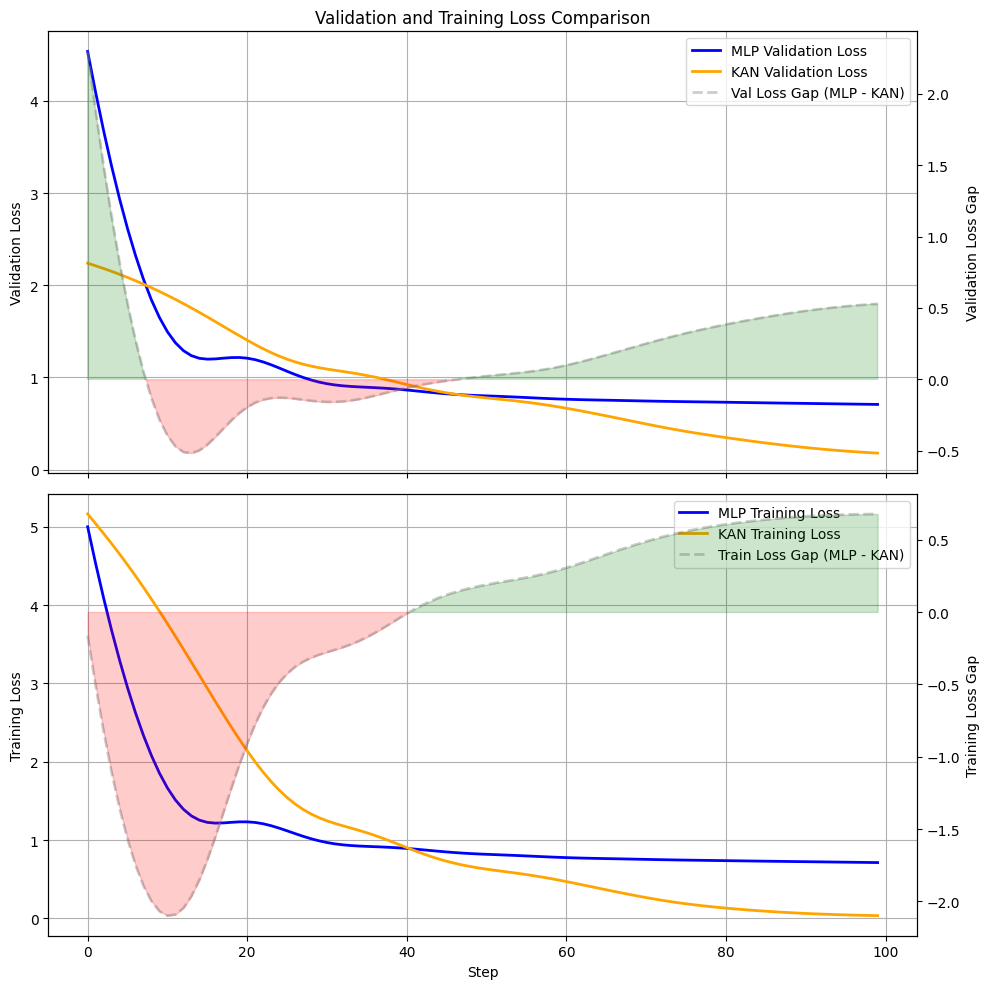

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load validation loss ===
df_mlp_val = pd.read_csv("./data/mlp_val_rmse.csv")
df_kan_val = pd.read_csv("./data/kan_val_rmse.csv")

steps_val = df_mlp_val["Step"]
mlp_val_loss = df_mlp_val["earthy-armadillo-26 - mlp_val_loss"]
kan_val_loss = df_kan_val["earthy-armadillo-26 - kan_val_rmse"]
val_residual = mlp_val_loss - kan_val_loss

# === Load training loss ===
df_mlp_train = pd.read_csv("./data/mlp_train_loss.csv")
df_kan_train = pd.read_csv("./data/kan_train_loss.csv")

steps_train = df_mlp_train["Step"]
mlp_train_loss = df_mlp_train["earthy-armadillo-26 - mlp_train_loss"]
kan_train_loss = df_kan_train["earthy-armadillo-26 - kan_train_loss"]
train_residual = mlp_train_loss - kan_train_loss

# === Create subplots ===
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# === Plot 1: Validation Loss ===
ax1.plot(steps_val, mlp_val_loss, label="MLP Validation Loss", color="blue", linewidth=2)
ax1.plot(steps_val, kan_val_loss, label="KAN Validation Loss", color="orange", linewidth=2)
ax1.set_ylabel("Validation Loss")
ax1.set_title("Validation and Training Loss Comparison")
ax1.grid(True)

# Secondary axis for validation loss gap
ax2 = ax1.twinx()
ax2.plot(steps_val, val_residual, label="Val Loss Gap (MLP - KAN)", color="gray", linestyle="--", alpha=0.4, linewidth=2)
ax2.fill_between(steps_val, 0, val_residual, where=(val_residual > 0), interpolate=True, color='green', alpha=0.2)
ax2.fill_between(steps_val, 0, val_residual, where=(val_residual < 0), interpolate=True, color='red', alpha=0.2)
ax2.set_ylabel("Validation Loss Gap")

# === Plot 2: Training Loss ===
ax3.plot(steps_train, mlp_train_loss, label="MLP Training Loss", color="blue", linewidth=2)
ax3.plot(steps_train, kan_train_loss, label="KAN Training Loss", color="orange", linewidth=2)
ax3.set_xlabel("Step")
ax3.set_ylabel("Training Loss")
ax3.grid(True)

# Secondary axis for training loss gap
ax4 = ax3.twinx()
ax4.plot(steps_train, train_residual, label="Train Loss Gap (MLP - KAN)", color="gray", linestyle="--", alpha=0.4, linewidth=2)
ax4.fill_between(steps_train, 0, train_residual, where=(train_residual > 0), interpolate=True, color='green', alpha=0.2)
ax4.fill_between(steps_train, 0, train_residual, where=(train_residual < 0), interpolate=True, color='red', alpha=0.2)
ax4.set_ylabel("Training Loss Gap")

# === Legends ===
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper right")

plt.tight_layout()
plt.show()


## Layer Plotting

In [72]:
from kan import *

from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)

# WandB Specific
entity = "hpml_project_spring25"
project = "Trash"

# Dataset Specific
n_var = 5
train_num = 1024
test_num = 1024

#Model Specific
seed = 42
grid_size = 16
grid_range = [-1, 1]
spline_order = 3
hidden_dim = [11, 11]
out_dim = 1

# Training Specfic
batch_size = -1
training_steps = 1000
opt = "Adam"
lr = 0.001



dataset = create_dataset(f, n_var=n_var, train_num=train_num, test_num=test_num, device='cuda')
dataset['train_input'].shape, dataset['train_label'].shape


(torch.Size([1024, 5]), torch.Size([1024, 1]))

checkpoint directory created: ./model
saving model version 0.0


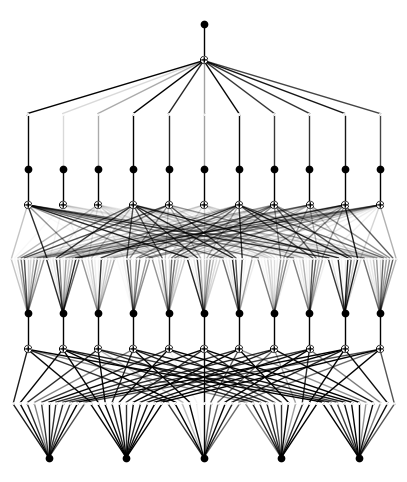

In [74]:
kan_model = KAN(width=[5, 11, 11, 1],
                grid=16,
                grid_range=[-1, 1],
                k=3,
                seed=42,
                device='cuda')

kan_model(dataset['train_input'])
kan_model.plot()

checkpoint directory created: ./model
saving model version 0.0


c:\Users\chaud\Desktop\!Back_this_folder!\College\Masters\Spring 2025\High Performance Machine Learning\optimized-kan\kan\MultKAN.py:819: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
c:\Users\chaud\Desktop\!Back_this_folder!\College\Masters\Spring 2025\High Performance Machine Learning\optimized-kan\kan\MultKAN.py:829: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  input_range = torch.std(preacts, dim=0) + 0.1
c:\Users\chaud\Desktop\!Back_this_folder!\College\Masters\Spring 2025\High Performance Ma

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     244.270ms      1672.73%     244.270ms      81.423ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▁▃▃▃▃▃▂▂▂▁▃▃▁▂▂▂▃▂▁▃▄▁▁▂▁▄▄█▇▅▄▂▂▂▂▃▂▃▄▂
inference_time,▁
reg,██▅▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▇▇▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▂▂▂▂▂
cpu_time_total (ms),948.5091


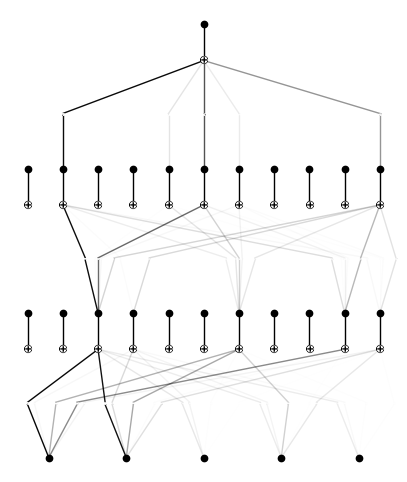

In [78]:
# train the kan_model
# Initialize W&B project
run = wandb.init(
    entity=entity,
    project='trash',
    name="Vanilla KAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device='cuda')
model(dataset['train_input'][[0]])

kan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

import time
start_time = time.perf_counter()

for _ in range(1000):
    model.eval()
    with torch.no_grad():
        model(dataset['test_input'])

end_time = time.perf_counter()
print(end_time - start_time)
wandb.log({"inference_time": end_time - start_time})

run.finish()
model.plot()

In [76]:
run = wandb.init(
    entity=entity,
    project='Trash',
    name="FastKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to('cuda')


fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

import time
start_time = time.perf_counter()

for _ in range(1000):
    model.eval()
    with torch.no_grad():
        model(dataset['test_input'])

end_time = time.perf_counter()
print(end_time - start_time)
wandb.log({"inference_time": end_time - start_time})


run.finish()



wandb: Currently logged in as: a-chaudhary (hpml_project_spring25) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


| train_loss: 1.84e-01 | test_loss: 3.70e-01 | : 100%|██████████| 1000/1000 [00:22<00:00, 44.27it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      72.912ms      2417.38%      72.912ms      24.304ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
inference_time,▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_loss,█▇▇▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),266.308
cuda_time_total (ms),3.01616


FastKANLayer(
  (rbf): RadialBasisFunction()
  (spline_linear): SplineLinear(in_features=80, out_features=11, bias=False)
  (base_linear): Linear(in_features=5, out_features=11, bias=True)
)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

FastKANLayer(
  (rbf): RadialBasisFunction()
  (spline_linear): SplineLinear(in_features=80, out_features=11, bias=False)
  (base_linear): Linear(in_features=5, out_features=11, bias=True)
)


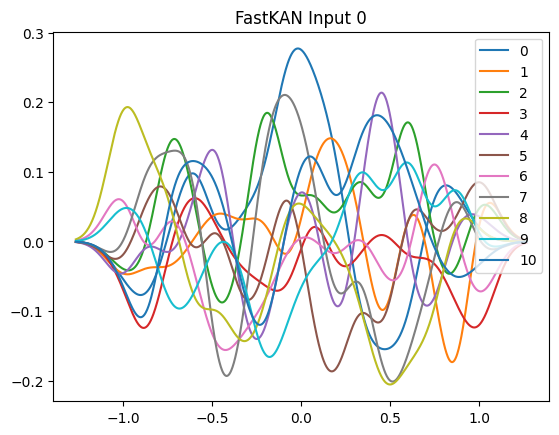

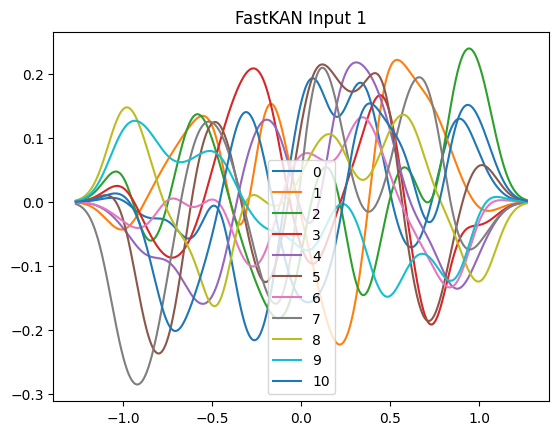

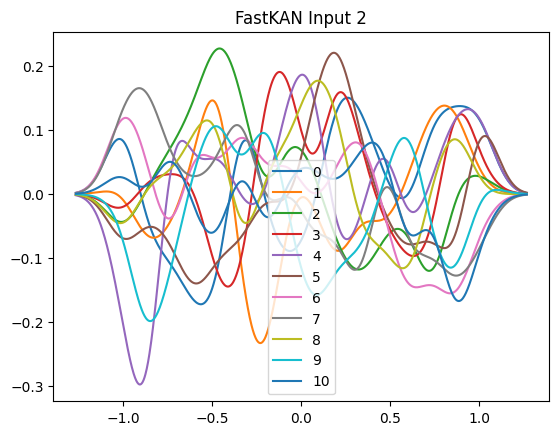

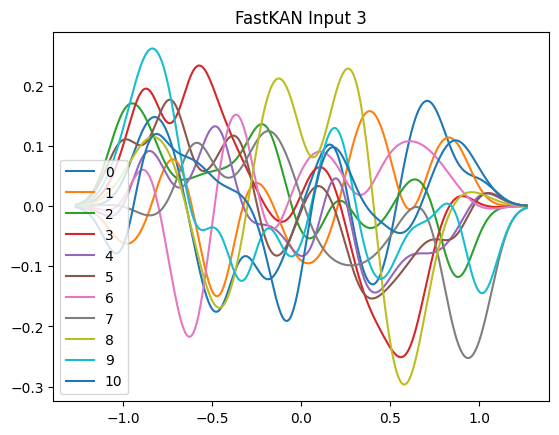

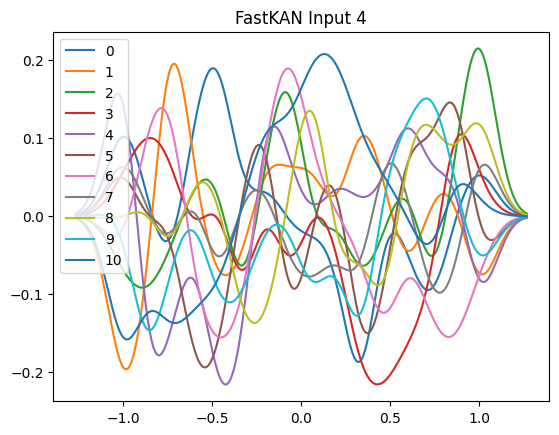

In [77]:
model = model.to('cpu')
for module in model.modules():
    if isinstance(module, FastKANLayer):
        print(module)
        for i in range(5):
            for j in range(11):
                x, y = module.plot_curve(i, j)
                plt.plot(x, y, label = f'{j}')
            plt.title(f'FastKAN Input {i}')
            plt.legend()
            plt.show()
        break

FastKANLayer(
  (rbf): RadialBasisFunction()
  (spline_linear): SplineLinear(in_features=80, out_features=11, bias=False)
  (base_linear): Linear(in_features=5, out_features=11, bias=True)
)


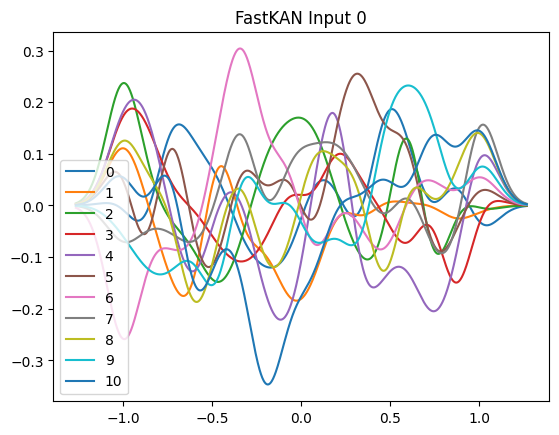

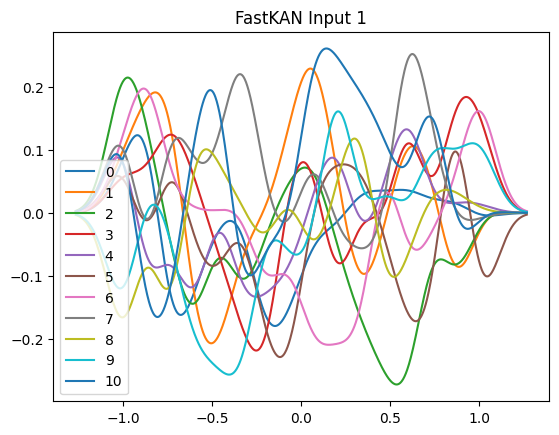

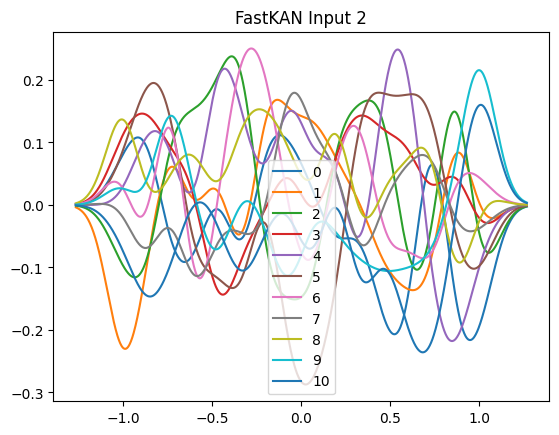

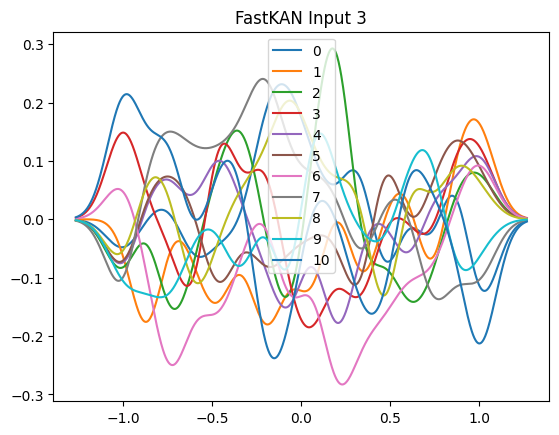

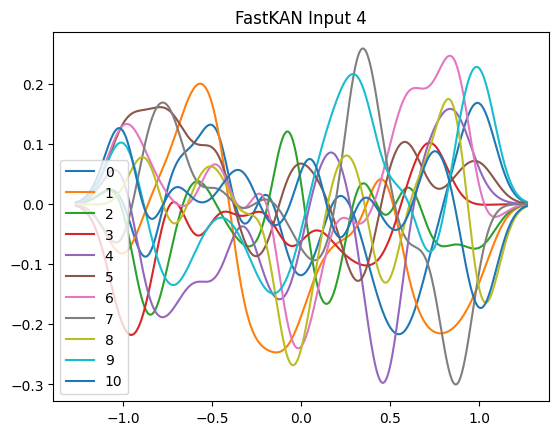

In [80]:
model = FastKAN(layers_hidden=[5, 11, 11, 1],
                grid_min=-1,
                grid_max=1,
                num_grids=16).to('cpu')

for module in model.modules():
    if isinstance(module, FastKANLayer):
        print(module)
        for i in range(5):
            for j in range(11):
                x, y = module.plot_curve(i, j)
                plt.plot(x, y, label = f'{j}')
            plt.title(f'FastKAN Input {i}')
            plt.legend()
            plt.show()
        break

## Old Plotting

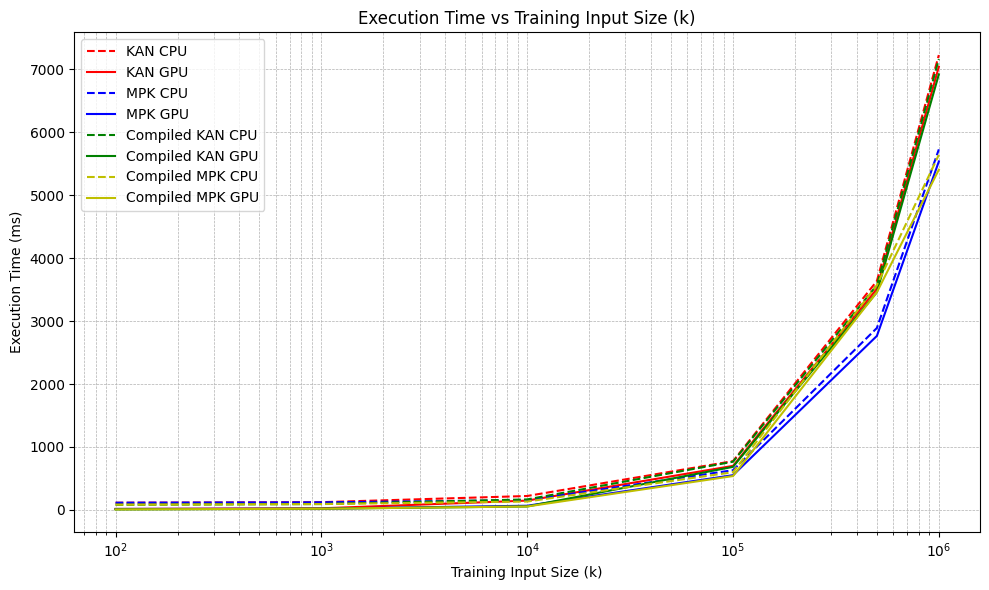

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Data
input_size_k = np.array([100, 1_000, 10_000, 100_000, 500_000, 1_000_000])

# Times
kan_cpu_ms = np.array([113.23, 121.71, 220.13, 774.24, 3637.00, 7228.00])  # in seconds
kan_gpu_ms = np.array([14.32, 24.36, 147.04, 698.83, 3513.00, 7043.00])
mpk_cpu_ms = np.array([113.04, 119.67, 152.64, 629.90, 2890.00, 5729.00])
mpk_gpu_ms = np.array([14.44, 19.08, 65.32, 550.86, 2764.00, 5537.00])

compiled_kan_cpu_ms = np.array([80.243, 92.333, 166.071, 765.147, 3571, 7163])
compiled_kan_gpu_ms = np.array([7.074, 17.998, 53.492, 683.475, 3458, 6921])
compiled_mpk_cpu_ms = np.array([81.996, 91.924, 132.071, 597.818, 3571, 5642])
compiled_mpk_gpu_ms = np.array([7.207, 18.018, 53.550, 537.077, 3458, 5406])

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot everything in milliseconds on the left axis
ax1.plot(input_size_k, kan_cpu_ms, 'r--', label='KAN CPU')
ax1.plot(input_size_k, kan_gpu_ms, 'r-', label='KAN GPU')
ax1.plot(input_size_k, mpk_cpu_ms, 'b--', label='MPK CPU')
ax1.plot(input_size_k, mpk_gpu_ms, 'b-', label='MPK GPU')

ax1.plot(input_size_k, compiled_kan_cpu_ms, 'g--', label='Compiled KAN CPU')
ax1.plot(input_size_k, compiled_kan_gpu_ms, 'g-', label='Compiled KAN GPU')
ax1.plot(input_size_k, compiled_mpk_cpu_ms, 'y--', label='Compiled MPK CPU')
ax1.plot(input_size_k, compiled_mpk_gpu_ms, 'y-', label='Compiled MPK GPU')
ax1.set_xlabel('Training Input Size (k)')
ax1.set_ylabel('Execution Time (ms)')
ax1.set_xscale('log')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left')


plt.title('Execution Time vs Training Input Size (k)')
plt.tight_layout()
plt.show()


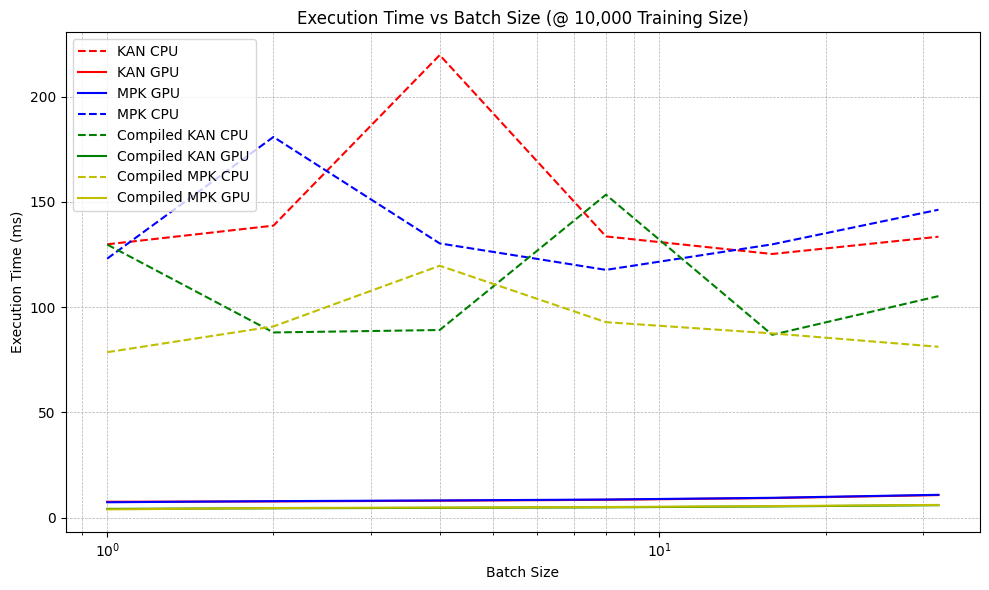

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data
input_size_k = np.array([1, 2, 4, 8, 16, 32])

# Times
kan_cpu_ms =             np.array([129.829, 138.696, 219.694, 133.575, 125.233, 133.435])  # in seconds
kan_gpu_ms =             np.array([7.589, 7.743, 8.077, 8.513, 9.333, 10.749])
mpk_cpu_ms =             np.array([123.033, 180.804, 130.260, 117.695, 129.809, 146.249])
mpk_gpu_ms =             np.array([7.342, 7.874, 8.207, 8.644, 9.464, 10.883])

compiled_kan_cpu_ms =    np.array([129.720, 87.977, 89.128, 153.396, 86.861, 105.219])
compiled_kan_gpu_ms =    np.array([4.203, 4.488, 4.701, 4.945, 5.383, 5.958])
compiled_mpk_cpu_ms =    np.array([78.605, 90.834, 119.661, 92.859, 87.533, 81.174])
compiled_mpk_gpu_ms =    np.array([3.954, 4.620, 4.840, 5.083, 5.518, 6.085])

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot everything in milliseconds on the left axis
ax1.plot(input_size_k, kan_cpu_ms, 'r--', label='KAN CPU')
ax1.plot(input_size_k, kan_gpu_ms, 'r-', label='KAN GPU')
ax1.plot(input_size_k, mpk_gpu_ms, 'b-', label='MPK GPU')
ax1.plot(input_size_k, mpk_cpu_ms, 'b--', label='MPK CPU')

ax1.plot(input_size_k, compiled_kan_cpu_ms, 'g--', label='Compiled KAN CPU')
ax1.plot(input_size_k, compiled_kan_gpu_ms, 'g-', label='Compiled KAN GPU')
ax1.plot(input_size_k, compiled_mpk_cpu_ms, 'y--', label='Compiled MPK CPU')
ax1.plot(input_size_k, compiled_mpk_gpu_ms, 'y-', label='Compiled MPK GPU')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Execution Time (ms)')
ax1.set_xscale('log')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left')

plt.title('Execution Time vs Batch Size (@ 10,000 Training Size)')
plt.tight_layout()
plt.show()
